In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Selecting numerical features for clustering & classification
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
target_col = 'Cluster'  # Cluster labels from K-Means

# Drop rows with missing values for clustering
product_numeric = product_df[numerical_cols].dropna().copy()


In [2]:
# Standardizing the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)

# Apply K-Means Clustering to generate cluster labels
optimal_clusters = 3  # Using k=3 as done in previous sections
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
product_numeric['Cluster'] = kmeans.fit_predict(product_scaled)

In [3]:
# Merge the cluster labels into product_df
product_df.loc[product_numeric.index, 'Cluster'] = product_numeric['Cluster']

# Verify that 'Cluster' is now in product_df
print("Updated columns in product_df:", product_df.columns)
print("Cluster value counts:\n", product_df['Cluster'].value_counts())



Updated columns in product_df: Index(['product_id', 'submission_time', 'rating', 'is_recommended',
       'helpfulness', 'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'price_usd', 'brand_name', 'skin_tone',
       'eye_color', 'skin_type', 'hair_color', 'Cluster'],
      dtype='object')
Cluster value counts:
 Cluster
0.0    49376
1.0    19315
2.0      780
Name: count, dtype: int64


In [4]:
# Drop rows with missing values for Naïve Bayes training
product_df = product_df[numerical_cols + [target_col]].dropna()

# Splitting features (X) and target (y)
X = product_df[numerical_cols]
y = product_df[target_col]

In [7]:
# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
# Initialize and train Gaussian Naïve Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [8]:
# Make predictions
y_pred = gnb.predict(X_test)

In [9]:
# Evaluate the model
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Confusion Matrix:
[[13578   825   410]
 [  763  4914   118]
 [    0     0   234]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93     14813
         1.0       0.86      0.85      0.85      5795
         2.0       0.31      1.00      0.47       234

    accuracy                           0.90     20842
   macro avg       0.70      0.92      0.75     20842
weighted avg       0.91      0.90      0.90     20842

Accuracy: 89.85%


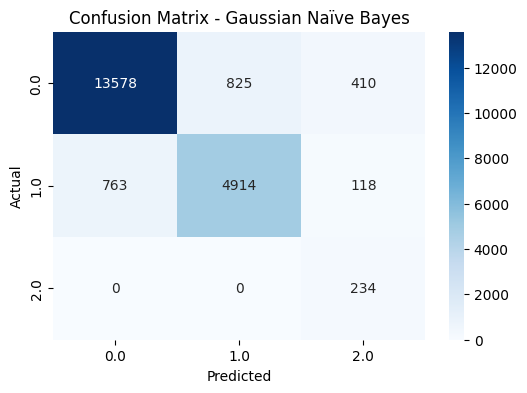

In [10]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Gaussian Naïve Bayes')
plt.show()